# Bluesky Data Science
## Part 07 - Analyzing Visual Content: Images, Alt Text, and Link Cards

June 2026
Copyright and distributed under an [MIT License](https://opensource.org/licenses/MIT)

*An [R Markdown counterpart](../../RMarkdown/Part%2007%20-%20Analyzing%20Visual%20Content/Part%2007%20-%20Analyzing%20Visual%20Content.Rmd) of this notebook, using the [bskyr](https://christophertkenny.com/bskyr/) package, lives in the parallel `RMarkdown/` directory.*


## Background

> **tl;dr**: A large share of social media communication is visual — photos, screenshots, memes, charts, video, and link previews — yet most data science tutorials stop at text. In this notebook we measure how Bluesky accounts use visual media, audit alt-text accessibility practices, map the domains behind link cards, and build a small, responsibly-collected image corpus.

Fifteen years of Twitter research taught us how to count words, but platforms became steadily more visual while our methods mostly did not. [Highfield & Leaver (2016)](https://doi.org/10.1080/22041451.2016.1155332) argued that social media research needed a methodological toolkit for "the visual turn" — and that building one raises new ethical questions, because images carry faces, locations, and contexts that text does not.

Bluesky is an unusually good place to take up that challenge, for three reasons. First, every post's media attachments are described by public, machine-readable **embed** records — an *embed* is the structured attachment that travels with a post (an image set, a video, a link preview, or a quoted post), stored separately from the post's text. Second, the image files themselves are served from an open **CDN** — a *content delivery network*, the layer of globally distributed cache servers that platforms use to deliver images and video quickly — so anyone with a URL can fetch a preview-sized copy. Third, and distinctively, Bluesky's interface nudges users to write **alt text**: the textual image description that a **screen reader** (software that blind and low-vision users rely on to speak interface content aloud or render it as braille) reads in place of the pixels. Bluesky even offers a setting that *requires* alt text before posting. If you have never written alt text yourself, [WebAIM's guide to alternative text](https://webaim.org/techniques/alttext/) is a ten-minute read that will make the middle of this notebook much more concrete.

That last affordance makes Bluesky a natural follow-up to [Gleason et al. (2019)](https://doi.org/10.1145/3308558.3313605), who found that when Twitter made alt text available behind an opt-in setting, only about **0.1% of image tweets** ended up with a description — a near-total failure of voluntary accessibility. Is Bluesky's alt-text culture measurably different? By the end of this notebook you will have an empirical answer for a small panel of accounts, and the tools to scale the question up.

### Learning objectives

1. Distinguish the AT Protocol's embed types — `images`, `video`, `external` (link cards), `record` (quote posts), and `recordWithMedia` — and classify any post's media.
2. Understand the difference between a post's *record* embed (what the author wrote) and its hydrated embed *view* (what clients render), and why raw JSON is sometimes more robust than typed SDK models.
3. Measure how often a panel of accounts posts each kind of media.
4. Audit **alt-text provision** as a quantitative accessibility measure, against the Twitter baseline of Gleason et al. (2019).
5. Extract and tabulate the **domains** behind link cards to characterize an information ecosystem.
6. Build a small image corpus on disk — thumbnails only, content-hash filenames, a manifest — and display it.
7. Know how CLIP-style image embeddings extend this pipeline to clustering and zero-shot classification of image *content*.

## Setup

The usual libraries, plus two we have not used before in this series:

* [Pillow](https://pillow.readthedocs.io/en/stable/) (imported as `PIL`, for historical reasons) is the standard Python library for opening, resizing, and saving images. We will use its [`Image`](https://pillow.readthedocs.io/en/stable/reference/Image.html) class to handle every pixel that touches disk.
* [`urllib.parse`](https://docs.python.org/3/library/urllib.parse.html), from Python's standard library, splits URLs into their components so we can pull the domain (`nytimes.com`) out of a full link-card URL.

Everything else is familiar from earlier parts: [`requests`](https://requests.readthedocs.io/) for HTTP, [`pandas`](https://pandas.pydata.org/docs/) for tables, and [`matplotlib`](https://matplotlib.org/stable/) for plots.

This notebook uses Pillow for all image handling. The optional computer-vision section at the end uses [`sentence-transformers`](https://www.sbert.net/) for CLIP embeddings; if it is not installed, that cell skips itself gracefully.

In [1]:
# Lets us talk to other servers on the web
import requests

# APIs spit out data in JSON
import json

# Politeness between API calls, file paths, hashing, URL parsing
import time
from pathlib import Path
from urllib.parse import urlparse
from collections import Counter

# Handling dates and times
from datetime import datetime, timezone

# DataFrames
import pandas as pd
import numpy as np

# Data visualization
%matplotlib inline
import matplotlib.pyplot as plt

# Image handling
from PIL import Image

As in every part of this series, `get_client()` from `bsky_client.py` returns an authenticated client if you saved credentials in an `atproto.json` file (see Part 00) and otherwise falls back to the unauthenticated public AppView at `https://public.api.bsky.app`. Everything in this notebook reads public data, so the unauthenticated client is all we need.

In [2]:
from bsky_client import get_client, is_authenticated

client = get_client()

No atproto.json found: using the unauthenticated public AppView.
Read endpoints work; search and write endpoints require logging in.


## 1. The anatomy of a Bluesky embed

When a Bluesky post carries media — a photo, a video, a preview card for a link — the attachment does not live inside the post's text. It lives in a separate structured field called the post's **embed**. Each kind of embed is defined by a **lexicon**, the AT Protocol's machine-readable schema language ([lexicon spec](https://atproto.com/specs/lexicon)); Bluesky's developer site documents them in the guide to [post embeds](https://docs.bsky.app/docs/advanced-guides/posts) and the [HTTP API reference](https://docs.bsky.app/docs/api/at-protocol-xrpc-api). The protocol defines a small family of them:

| Lexicon | What it is |
|---|---|
| `app.bsky.embed.images` | One or more attached images, each with optional **alt text** and an aspect ratio |
| `app.bsky.embed.video` | An attached video with a thumbnail |
| `app.bsky.embed.external` | A **link card**: a URL plus the title, description, and preview image scraped from it |
| `app.bsky.embed.record` | A **quote post**: a reference to another record |
| `app.bsky.embed.recordWithMedia` | A quote post *plus* attached media (images, video, or a link card) |

Each embed appears in **two places** in an API response, and the distinction matters:

* `post.record.embed` — the raw record the **author** wrote. The image files themselves are not stored inside the record: they are **blobs**, the protocol's term for arbitrary binary files (images, video) kept on the author's data server ([blob spec](https://atproto.com/specs/blob)). The record points at each blob with a **content hash** — a short, unique fingerprint computed from the file's bytes, so the same file always yields the same hash and changing a single pixel changes it completely. A content hash *identifies* a file, but it is not a URL you can click.
* `post.embed` — the hydrated **view** that the AppView (the indexing server that assembles what clients display) constructs for clients. The view resolves blob references into ready-to-fetch CDN URLs — `thumb` for a small preview rendition (a **thumbnail**) and `fullsize` for a larger one — carries the same alt text, and marks itself with a `#view` suffix on its `$type` (e.g. `app.bsky.embed.images#view`).

For analysis we generally want the view — it has the URLs — but a robust classifier should fall back to the record embed when the view is missing (for example, a quote of a deleted post).

### When typed SDK models meet a platform in flux

There is a practical wrinkle. Embed lexicons are the fastest-moving part of the protocol: in 2025 Bluesky shipped `app.bsky.embed.gallery`, a multi-image carousel, and posts using it appear in feeds *before* SDK releases can model them. The [atproto SDK](https://atproto.blue/) validates every response against its known types, so a single gallery post can make an entire `get_author_feed` page raise a validation error. If the next cell prints an error, nothing is wrong with your setup — the error *is* the lesson. Watch:

In [3]:
# The official account posts feature announcements with the newest embed types,
# so its feed is exactly where SDK models go to be surprised.
try:
    feed = client.get_author_feed(actor='bsky.app', limit=100)
    print(f"The SDK parsed {len(feed.feed)} posts -- no unmodeled embed types on this page.")
except Exception as error:
    print(f"The SDK raised {type(error).__name__}:\n")
    print(str(error)[:400], '...')

The SDK raised ModelError:

1 validation error for Response
feed.0.post.embed
  Input tag 'app.bsky.embed.gallery#view' found using 'py_type' | '$type' does not match any of the expected tags: 'app.bsky.embed.images#view', 'app.bsky.embed.video#view', 'app.bsky.embed.external#view', 'app.bsky.embed.record#view', 'app.bsky.embed.recordWithMedia#view' [type=union_tag_invalid, input_value={'items': [{'thumbnail': ...sky.embed.g ...


This is not a bug so much as a fact of life on an actively evolving protocol — one of the reproducibility hazards we flagged back in Part 01. The SDK's typed models are a convenience, not the data itself. Under the hood, every Bluesky endpoint is just an HTTPS request to a URL like `https://public.api.bsky.app/xrpc/app.bsky.feed.getAuthorFeed` — a convention the AT Protocol calls [XRPC](https://atproto.com/specs/xrpc) — that returns plain JSON. Fetching that JSON directly with [`requests`](https://requests.readthedocs.io/) never fails validation, because nothing validates it: we get dictionaries and lists, exactly as the server sent them, including embed types invented yesterday.

For this notebook we therefore collect feeds as **raw JSON**, using helper functions in this part's `media.py` module. (We keep the SDK client around for endpoints it handles fine, like profile lookups.) The trade-off is real and worth naming: typed models catch your typos and document the schema; raw dictionaries put the burden of careful key access — `.get()` with defaults everywhere — on you.

In [4]:
import media

# One page of app.bsky.feed.getAuthorFeed as a plain Python dict
page = media.get_author_feed_page('bsky.app', limit=30)

print(f"Got {len(page['feed'])} feed items; cursor = {page['cursor'][:25]}...")

# The same embed types, now as dictionary keys instead of model attributes
Counter(item['post'].get('embed', {}).get('$type') for item in page['feed'])

Got 30 feed items; cursor = 2026-03-19T16:26:13.953Z...


Counter({'app.bsky.embed.record#view': 10,
         None: 8,
         'app.bsky.embed.external#view': 4,
         'app.bsky.embed.images#view': 4,
         'app.bsky.embed.video#view': 2,
         'app.bsky.embed.gallery#view': 1,
         'app.bsky.embed.recordWithMedia#view': 1})

There they are — including, depending on the day you run this, types the SDK has never heard of. `media.py` provides `classify_embed(post)`, which maps any post dict onto a short class name. It prefers the hydrated view, falls back to the record embed, normalizes `recordWithMedia` to `record_with_media`, and folds the new `gallery` carousels in with `images` (semantically they are multi-image embeds). Here is the heart of it:

In [5]:
import inspect

print(inspect.getsource(media._normalize_embed_type))
print(inspect.getsource(media.classify_embed))

def _normalize_embed_type(type_string):
    """Map a ``$type`` like ``app.bsky.embed.images#view`` to a short class."""
    if not type_string:
        return "none"
    name = type_string.removeprefix("app.bsky.embed.").split("#")[0]
    if name == "recordWithMedia":
        return "record_with_media"
    if name == "gallery":  # multi-image carousel; semantically an image embed
        return "images"
    if name in EMBED_CLASSES:
        return name
    return "other:" + name  # future lexicons we have not seen yet

def classify_embed(post):
    """Classify a post dict's embed into one of EMBED_CLASSES.

    Prefers the hydrated *view* (``post["embed"]``), which is what clients
    render, and falls back to the author's raw record (``post["record"]
    ["embed"]``) when the AppView did not hydrate a view (e.g. a quoted post
    that was deleted or blocked).
    """
    view = post.get("embed") or {}
    record_embed = (post.get("record") or {}).get("embed") or {}
    type_string = v

## 2. Collecting a media panel

To say anything about media *practices* we need a **panel**: a fixed set of accounts whose posts we observe, so that differences between accounts (rather than a jumble of one-off posts) become the unit of analysis. We want accounts with different communication styles. Following this series' conventions we start from the two standing example accounts — `bsky.app` (the official platform account) and `nytimes.com` (The New York Times) — and add organizational accounts with contrasting communication styles.

How do we find those? When a post mentions another account ("@someone"), the mention is recorded in the post's `facets` — the structured annotations over a post's text that we met in Part 02 (see the [rich text guide](https://docs.bsky.app/docs/advanced-guides/post-richtext)). A mention facet stores the mentioned account's **DID** (decentralized identifier — the stable, machine-readable ID behind a handle, which never changes even when the handle does). As a discovery demo, we page through ~500 of `nytimes.com`'s recent posts with [`app.bsky.feed.getAuthorFeed`](https://docs.bsky.app/docs/api/app-bsky-feed-get-author-feed), count mention DIDs, and resolve the most frequent DIDs back to human-readable handles:

In [6]:
# Scan ~500 recent posts by nytimes.com for mention facets
mention_counts = Counter()
cursor = None

for _ in range(5):
    page = media.get_author_feed_page('nytimes.com', cursor=cursor, filter='posts_with_replies')
    for item in page['feed']:
        for facet in item['post']['record'].get('facets') or []:
            for feature in facet['features']:
                if feature['$type'] == 'app.bsky.richtext.facet#mention':
                    mention_counts[feature['did']] += 1
    cursor = page.get('cursor')
    if not cursor:
        break
    time.sleep(0.1)

# Mentions store DIDs; resolve the most-mentioned ones to handles with the SDK
top_dids = [did for did, n in mention_counts.most_common(8)]
profiles = client.get_profiles(actors=top_dids)

for profile in profiles.profiles:
    print(f"{mention_counts[profile.did]:>3}  {profile.handle:<28} {profile.display_name}")

 39  theathletic.com              The Athletic
 32  nytopinion.nytimes.com       New York Times Opinion
 15  theathleticfc.bsky.social    The Athletic | Football
  1  emmagf.bsky.social           Emma Fitzsimmons
  1  edenweingart.bsky.social     
  1  thomaslfriedman.bsky.social  Thomas L Friedman
  1  rebeccasolnit.bsky.social    Rebecca Solnit
  1  jasonzinoman.bsky.social     Jason Zinoman


The accounts a newsroom mentions most turn out to be its own sister accounts and journalists — useful for seeing how the discovery technique works, but a panel built only from them would be six flavors of the same institution. So we hand-pick instead: organizational accounts with contrasting communication styles (organizations post a lot of media, and studying organizations rather than private individuals is the ethically conservative choice — more on this at the end). Our panel is the two standing accounts plus four more:

In [7]:
PANEL = [
    'bsky.app',                 # the official platform account
    'npr.org',                  # NPR, national public radio
    'boulderrl.bsky.social',    # Boulder Reporting Lab, a nonprofit local newsroom
    'propublica.org',           # ProPublica, investigative journalism
    'nytimes.com',              # The New York Times
    'knightcolumbia.org',       # Knight First Amendment Institute
]

POSTS_PER_ACCOUNT = 135   # 6 accounts x 135 posts ~= 800 posts
COLLECTED_AT = datetime.now(timezone.utc)

all_posts = {}
for actor in PANEL:
    all_posts[actor] = media.collect_author_posts(actor, max_posts=POSTS_PER_ACCOUNT, sleep=0.1)
    print(f"{actor:<24} {len(all_posts[actor]):>4} posts")

print(f"\nTotal: {sum(len(p) for p in all_posts.values())} posts, collected {COLLECTED_AT:%Y-%m-%d %H:%M} UTC")

bsky.app                  135 posts


npr.org                   135 posts


boulderrl.bsky.social     135 posts


propublica.org            135 posts


nytimes.com               135 posts


knightcolumbia.org        135 posts

Total: 810 posts, collected 2026-06-10 16:26 UTC


Two collection decisions worth making explicit, because they shape every number below. First, `collect_author_posts` **skips reposts**: a repost shows someone else's media choices, and we want to attribute practices like alt-text provision to the account that actually made them. Second, we used the `posts_no_replies` filter, so we are sampling each account's primary, public-facing output rather than its conversations. Both choices are recorded in `media.py` and in the metadata file we save at the end — when a collection decision changes your numbers, future-you (and your readers) need to be able to find it.

Now flatten every post into one tidy row per post with `media.post_row()`, which records the embed class plus the media details we will analyze — image counts, alt text, and link-card domains — in a pandas [`DataFrame`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html):

In [8]:
rows = [media.post_row(post) for posts in all_posts.values() for post in posts]
df = pd.DataFrame(rows)

print(f"{len(df)} posts from {df['author'].nunique()} accounts")
df.head()

810 posts from 6 accounts


,uri,author,created_at,text_length,embed_class,n_images,n_images_with_alt,alt_text,external_domain,external_uri,like_count,repost_count
0,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky...,bsky.app,2026-06-08T21:10:01.530Z,207,images,5,5,We've increased the number of photos you can a...,NaN,NaN,10407,2108
1,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky...,bsky.app,2026-06-04T17:45:11.965Z,97,none,0,0,,NaN,NaN,14609,2117
2,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky...,bsky.app,2026-06-02T21:36:20.000Z,261,none,0,0,,NaN,NaN,2086,388
3,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky...,bsky.app,2026-05-28T18:09:50.000Z,177,images,1,1,The Bluesky and Standard.site logos sharing an...,NaN,NaN,3143,539
4,at://did:plc:z72i7hdynmk6r22z27h6tvur/app.bsky...,bsky.app,2026-05-15T14:54:22.994Z,128,record,0,0,,NaN,NaN,2211,182


### A worked example of each embed type

Before aggregating, let's look at one real example of every embed class the panel produced, to connect the abstract type names to actual posts. As you read each example, match it back to the lexicon table in Section 1: an `images` post carries alt text, a `video` post carries a thumbnail URL and an aspect ratio, an `external` post carries a domain and a scraped title, and the two `record` flavors point at another post. (Because this runs against the live network, the specific posts — and even which classes appear — will differ each time you run it.)

In [9]:
def describe_embed(post):
    """Print a compact, human-readable summary of one post's embed."""
    text = (post['record'].get('text') or '').replace('\n', ' ')
    print(f"  @{post['author']['handle']}: \"{text[:80]}{'...' if len(text) > 80 else ''}\"")
    view = post.get('embed') or {}
    view_type = view.get('$type', '(no embed view)')
    print(f"  view $type: {view_type}")

    images = list(media.iter_images(post))
    if images:
        first = images[0]
        alt = f'"{first["alt"][:60]}..."' if first['alt'] else '(none)'
        print(f"  {len(images)} image(s); first alt text: {alt}")
    if view_type.startswith('app.bsky.embed.video'):
        ratio = view.get('aspectRatio') or {}
        print(f"  video thumbnail: {str(view.get('thumbnail'))[:60]}...")
        print(f"  aspect ratio: {ratio.get('width')}x{ratio.get('height')}")
    card = media.external_info(post)
    if card:
        print(f"  link card -> {card['domain']}: \"{card['title'][:60]}\"")
    if view_type.startswith(('app.bsky.embed.record#', 'app.bsky.embed.recordWithMedia')):
        quoted = view.get('record', {})
        quoted = quoted.get('record', quoted)  # recordWithMedia nests one level deeper
        quoted_author = (quoted.get('author') or {}).get('handle', '(unavailable)')
        print(f"  quotes a post by @{quoted_author}")


# First example of each class, in a fixed display order
examples = {}
for posts in all_posts.values():
    for post in posts:
        examples.setdefault(media.classify_embed(post), post)

for embed_class in ['images', 'video', 'external', 'record', 'record_with_media', 'none']:
    if embed_class in examples:
        print(f"--- {embed_class} " + '-' * (50 - len(embed_class)))
        describe_embed(examples[embed_class])
        print()

--- images --------------------------------------------
  @bsky.app: "v1.123 is live! You can now attach up to 10 photos in posts.   We listened to yo..."
  view $type: app.bsky.embed.gallery#view
  5 image(s); first alt text: "We've increased the number of photos you can attach to a pos..."

--- video ---------------------------------------------
  @bsky.app: "v1.121 is live!  We've increased the quality of photos in posts by doubling the ..."
  view $type: app.bsky.embed.video#view
  video thumbnail: https://video.bsky.app/watch/did%3Aplc%3Az72i7hdynmk6r22z27h...
  aspect ratio: 381x800

--- external ------------------------------------------
  @bsky.app: "Read David Imel’s summary of ATmosphereConf, a recent gathering of folks buildin..."
  view $type: app.bsky.embed.external#view
  link card -> davidimel.substack.com: "Bluesky is doubling down"

--- record --------------------------------------------
  @bsky.app: "THE INTERNET FOR $600: This social media app now boasts at least 200

## 3. How visual is the panel?

The most basic descriptive question: what fraction of posts carry each kind of embed? [`value_counts(normalize=True)`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html) converts raw counts into shares that sum to 1, which we plot as a bar chart. First overall, then by account.

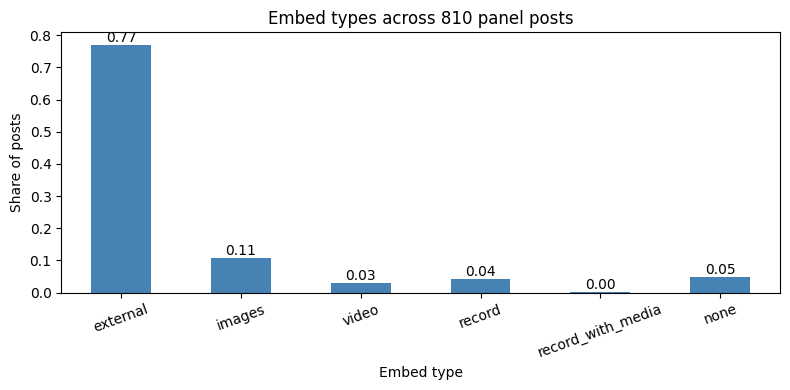

In [10]:
embed_order = ['external', 'images', 'video', 'record', 'record_with_media', 'none']
embed_shares = df['embed_class'].value_counts(normalize=True).reindex(embed_order).fillna(0)

fig, ax = plt.subplots(figsize=(8, 4))
embed_shares.plot.bar(ax=ax, color='steelblue')
ax.set_ylabel('Share of posts')
ax.set_xlabel('Embed type')
ax.set_title(f'Embed types across {len(df)} panel posts')
ax.bar_label(ax.containers[0], fmt='%.2f')
plt.xticks(rotation=20)
plt.tight_layout()

On this panel, posts with **no** embed — pure text — are a minority. But the overall bar hides enormous differences between accounts, which is the real finding. To see them we build an account-by-embed-type table with [`pd.crosstab(..., normalize='index')`](https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html): each row is one account and is normalized to sum to 1, so accounts that post at different volumes are directly comparable. A stacked horizontal bar chart then shows each account's *composition* at a glance:

embed_class,external,images,video,record,record_with_media,none
author,,,,,,
bsky.app,0.21,0.28,0.05,0.19,0.01,0.26
npr.org,1.00,0.00,0.00,0.00,0.00,0.00
boulderrl.bsky.social,0.99,0.00,0.00,0.00,0.00,0.01
propublica.org,0.87,0.08,0.04,0.01,0.00,0.00
nytimes.com,0.87,0.13,0.00,0.00,0.00,0.00
knightcolumbia.org,0.68,0.15,0.10,0.06,0.00,0.01


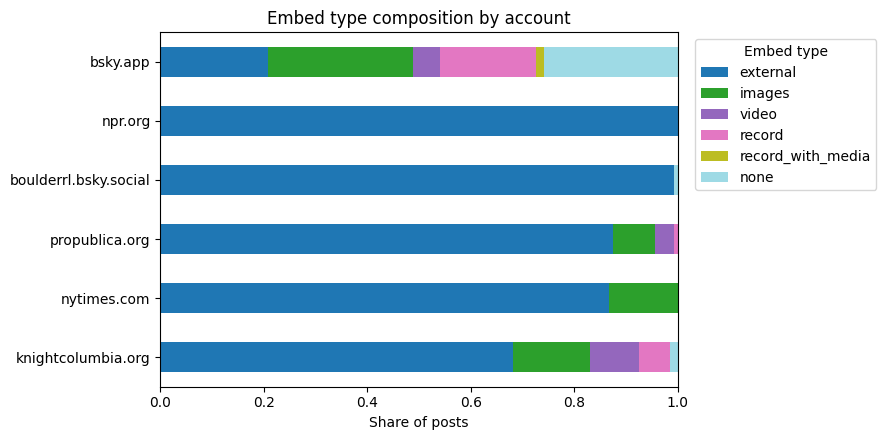

In [11]:
by_account = (pd.crosstab(df['author'], df['embed_class'], normalize='index')
                .reindex(columns=embed_order, fill_value=0)
                .loc[PANEL])

fig, ax = plt.subplots(figsize=(9, 4.5))
by_account.plot.barh(stacked=True, ax=ax, colormap='tab20')
ax.set_xlabel('Share of posts')
ax.set_ylabel('')
ax.set_title('Embed type composition by account')
ax.legend(title='Embed type', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.invert_yaxis()
plt.tight_layout()

by_account.round(2)

Each account has a visual *signature*. The news organizations are link-card machines — most of their posts exist to push readers to articles on their own websites. The platform account mixes announcement screenshots, videos, and quote posts. The individual academic quotes other posts far more than he attaches media. These signatures are themselves data: an account's embed mix encodes its communicative role.

### Images per post and aspect ratios

For posts that carry images (including the image half of `recordWithMedia` embeds), how many do they attach, and what shapes are they? An image's **aspect ratio** is its width divided by its height: values above 1 are landscape (wider than tall), values below 1 are portrait (taller than wide), and exactly 1 is square. The embed view's `aspectRatio` field reports width and height in the metadata, which means we can study image *shape* without downloading a single pixel.

In [12]:
# Every individual image across the whole panel, via media.iter_images
image_records = [
    {'author': post['author']['handle'], **img}
    for posts in all_posts.values() for post in posts
    for img in media.iter_images(post)
]
images_df = pd.DataFrame(image_records)

image_posts = df[df['n_images'] > 0]
print(f"{len(image_posts)} posts carry {len(images_df)} images "
      f"({image_posts['n_images'].mean():.2f} images per image-post)")

image_posts['n_images'].value_counts().sort_index()

88 posts carry 96 images (1.09 images per image-post)


n_images
1    84
2     2
3     1
5     1
Name: count, dtype: int64

The histogram below ([`ax.hist`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.hist.html)) shows the distribution of aspect ratios, with dashed reference lines at three culturally meaningful shapes: 9:16 (a phone held upright — most phone photos and app screenshots), 1:1 (square — the classic designed social-media card), and 16:9 (a widescreen monitor or video frame). One wrinkle to anticipate: `aspectRatio` is an *optional* field in the lexicon, so some images simply do not report it. We drop those rows with [`dropna`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html) and say how many we dropped in the plot title — silently discarding data is how analyses quietly go wrong.

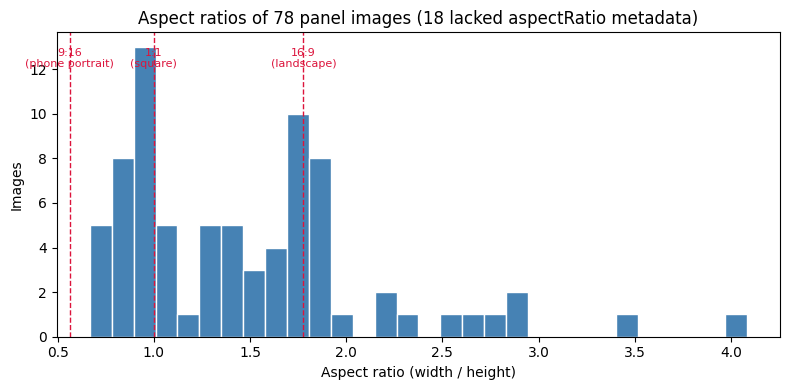

In [13]:
# Aspect ratio = width / height; >1 is landscape, <1 is portrait
with_ratio = images_df.dropna(subset=['width', 'height']).copy()
with_ratio['aspect'] = with_ratio['width'] / with_ratio['height']

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(with_ratio['aspect'], bins=30, color='steelblue', edgecolor='white')
for value, label in [(9/16, '9:16\n(phone portrait)'), (1.0, '1:1\n(square)'), (16/9, '16:9\n(landscape)')]:
    ax.axvline(value, color='crimson', linestyle='--', linewidth=1)
    ax.text(value, ax.get_ylim()[1] * 0.95, label, ha='center', va='top', fontsize=8, color='crimson')
ax.set_xlabel('Aspect ratio (width / height)')
ax.set_ylabel('Images')
ax.set_title(f'Aspect ratios of {len(with_ratio)} panel images '
             f'({len(images_df) - len(with_ratio)} lacked aspectRatio metadata)')
plt.tight_layout()

Aspect ratios are a cheap, download-free proxy for image *genre*: spikes near 16:9 usually mean screenshots, video stills, and link-preview graphics; 1:1 suggests designed social cards and profile-style photos; tall portrait ratios suggest phone photos and screenshots of other apps. A content analysis would verify those guesses against the pixels — which is exactly what Sections 6 and 7 set up.

## 4. Alt text: accessibility as a measurable practice

This is the centerpiece of the notebook. **Alt text** is the description a sighted author writes so that blind and low-vision users, whose screen readers cannot interpret pixels, get the content of an image. Good alt text conveys the image's *function and content* in context — "Line chart showing Bluesky signups spiking after the November announcement" rather than "chart" — and [WebAIM's alt-text guidance](https://webaim.org/techniques/alttext/) is the standard accessible reference on what that means in practice. Whether authors actually write it is a concrete, countable behavioral measure of how much a community's accessibility norms are worth.

The Twitter baseline is grim. [Gleason et al. (2019)](https://doi.org/10.1145/3308558.3313605) audited 1.09 million image tweets and found that only **0.1%** had alt text — even though Twitter had offered the feature since 2016 — because it was buried behind an opt-in setting that almost nobody enabled. Their title quotes a frustrated screen-reader user: *"It's almost like they're trying to hide it."*

Bluesky made different design choices: the alt-text field is visible by default in the posting interface, images without descriptions are badged in some clients, and a [user setting](https://bsky.app/settings/accessibility) can **require** alt text before a post will send. Did the design choices and the community norms that grew around them move the number? We compute three related rates, because they answer slightly different questions: the share of *image posts* where **all** images are described (the strictest standard — a screen-reader user gets the whole post), the share where **any** image is described, and the share of *individual images* with a description (the number most directly comparable to Gleason et al.). Among our panel's image posts:

In [14]:
total_images = images_df.shape[0]
images_with_alt = (images_df['alt'].str.strip() != '').sum()
posts_fully_alt = (image_posts['n_images_with_alt'] == image_posts['n_images']).sum()
posts_any_alt = (image_posts['n_images_with_alt'] > 0).sum()

print(f"Image posts in panel:              {len(image_posts)}")
print(f"  ... with alt text on ALL images: {posts_fully_alt} ({posts_fully_alt / len(image_posts):.1%})")
print(f"  ... with alt text on ANY image:  {posts_any_alt} ({posts_any_alt / len(image_posts):.1%})")
print(f"Individual images:                 {total_images}")
print(f"  ... with non-empty alt text:     {images_with_alt} ({images_with_alt / total_images:.1%})")
print()
print(f"Twitter baseline (Gleason et al. 2019): 0.1% of image tweets")

Image posts in panel:              88
  ... with alt text on ALL images: 63 (71.6%)
  ... with alt text on ANY image:  63 (71.6%)
Individual images:                 96
  ... with non-empty alt text:     69 (71.9%)

Twitter baseline (Gleason et al. 2019): 0.1% of image tweets


Orders of magnitude above the Twitter baseline — even the *lowest-provision* account in this panel will typically beat 0.1% by an order of magnitude or more. But provision is far from uniform: it is a per-account practice, so let's measure it per account:

,images,alt_rate
author,,
knightcolumbia.org,22,0.045
nytimes.com,18,0.778
bsky.app,44,0.955
propublica.org,12,1.000


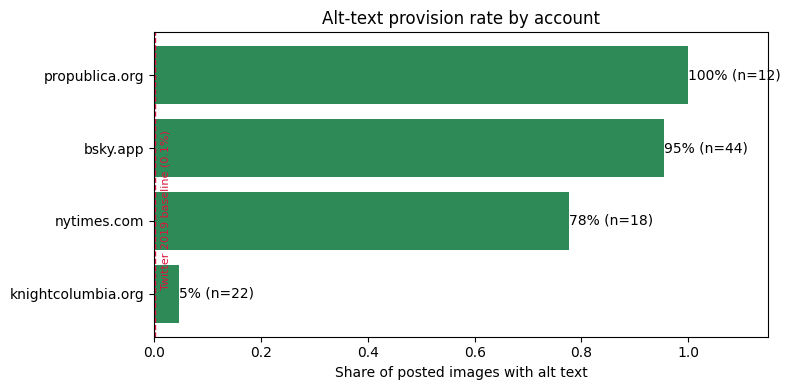

In [15]:
alt_by_account = (
    images_df.assign(has_alt=images_df['alt'].str.strip() != '')
             .groupby('author')['has_alt']
             .agg(images='count', alt_rate='mean')
             .sort_values('alt_rate')
)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(alt_by_account.index, alt_by_account['alt_rate'], color='seagreen')
ax.bar_label(bars, labels=[f"{r:.0%} (n={int(n)})"
                           for r, n in zip(alt_by_account['alt_rate'], alt_by_account['images'])])
ax.axvline(0.001, color='crimson', linestyle='--', linewidth=1)
ax.text(0.012, 0.05, 'Twitter 2019 baseline (0.1%)', color='crimson', fontsize=8, rotation=90, va='bottom')
ax.set_xlim(0, 1.15)
ax.set_xlabel('Share of posted images with alt text')
ax.set_title('Alt-text provision rate by account')
plt.tight_layout()

alt_by_account.round(3)

Treat the per-account rates with appropriate humility — some accounts post few images, so their rates have wide error bars — but the pattern is informative. Accounts embedded in Bluesky's early-adopter culture (where "no alt text, no repost" is a common stated norm) describe nearly everything; organizational accounts that cross-post from other platforms via scheduling tools often describe much less, because the tooling, not the platform, sets the default.

### How much do people write?

Provision is binary; *quality* is not. Description length is a crude but useful first proxy — a five-word alt text and a five-sentence one are very different accessibility experiences.

count     69.0
mean     133.1
std      113.1
min       16.0
25%       60.0
50%      109.0
75%      149.0
max      726.0
Name: alt, dtype: float64

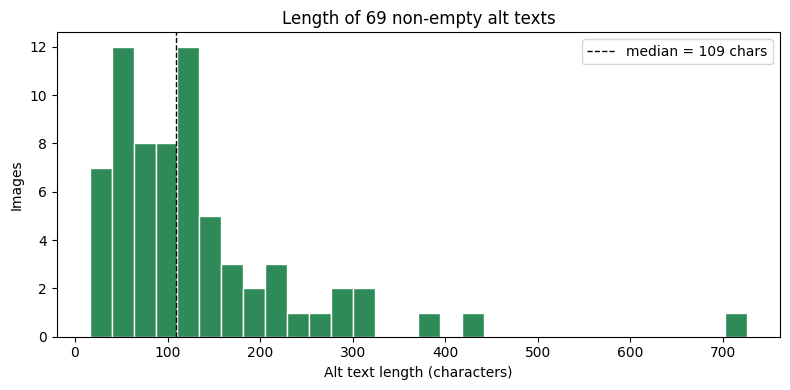

In [16]:
alt_lengths = images_df.loc[images_df['alt'].str.strip() != '', 'alt'].str.len()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(alt_lengths, bins=30, color='seagreen', edgecolor='white')
ax.axvline(alt_lengths.median(), color='black', linestyle='--', linewidth=1,
           label=f'median = {alt_lengths.median():.0f} chars')
ax.set_xlabel('Alt text length (characters)')
ax.set_ylabel('Images')
ax.set_title(f'Length of {len(alt_lengths)} non-empty alt texts')
ax.legend()
plt.tight_layout()

alt_lengths.describe().round(1)

Summary statistics flatten a lot. To get a feel for what these descriptions actually *are*, let's read two real ones — the shortest and the longest in the panel. Watching the extremes is a good habit with any text field: the shortest values reveal perfunctory compliance (a single word, a stray character), while the longest reveal what dedicated describers are doing with the space.

In [17]:
# A couple of real examples from organizational accounts, shortest and longest
described = images_df[images_df['alt'].str.strip() != ''].copy()
described['alt_len'] = described['alt'].str.len()

for label, row in [('Shortest', described.nsmallest(1, 'alt_len').iloc[0]),
                   ('Longest', described.nlargest(1, 'alt_len').iloc[0])]:
    print(f"{label} ({row['alt_len']} chars, @{row['author']}):")
    print(f'  "{row["alt"][:300]}{"..." if row["alt_len"] > 300 else ""}"')
    print()

Shortest (16 chars, @bsky.app):
  "pixelated potato"

Longest (726 chars, @propublica.org):
  "Graphic displaying how hundreds of staff who do work related to nuclear reactors and their safety have left and not been replaced. The data is categorized into six sections: Nuclear Reactor Regulation, Nuclear Material Safety and Safeguards, Nuclear Regulatory Research, Nuclear Security and Incident..."



Note that many alt texts are longer than the 300-character post limit — Bluesky allows up to 2,000 characters of alt text, and people use them. Some of the longest "alt texts" in the wild are actually full transcriptions of screenshotted documents, which serves screen-reader users and, incidentally, makes the *image's* content searchable and analyzable as text. For a researcher, alt text is a gift twice over: it is an accessibility measure, *and* it is a free, author-written caption corpus for the multimodal analyses in Section 7.

The research framing matters here. Gleason et al. were not just counting; they showed that a **design choice** (hiding the feature) produced a **population-level accessibility failure**. Bluesky's contrasting choices — visible field, optional enforcement, community norms — constitute a natural comparison. A full study would sample accounts systematically (not a six-account convenience panel), track provision over account tenure (do newcomers learn the norm?), and compare across communities on the same platform.

## 5. Link cards: who points where?

`external` embeds — link cards — are the connective tissue between Bluesky and the rest of the web. Every card carries the destination URL, so with [`urlparse`](https://docs.python.org/3/library/urllib.parse.html#urllib.parse.urlparse) we can extract each URL's **domain** (the `nytimes.com` part) and ask: which websites does this panel's attention point to? `media.external_info` already parsed and normalized the domain for every row — lowercased, with any leading `www.` stripped, so `www.NYTimes.com` and `nytimes.com` count as the same place. We tabulate the ten most-linked domains and each one's share of all link cards:

In [18]:
external_posts = df[df['external_domain'].notna()]
print(f"{len(external_posts)} posts with link cards across {external_posts['external_domain'].nunique()} distinct domains\n")

top_domains = (external_posts['external_domain']
               .value_counts()
               .head(10)
               .rename('link cards')
               .to_frame())
top_domains['share'] = (top_domains['link cards'] / len(external_posts)).round(3)
top_domains

625 posts with link cards across 39 distinct domains



,link cards,share
external_domain,,
n.pr,134,0.214
boulderreportinglab.org,133,0.213
nyti.ms,116,0.186
propublica.org,112,0.179
knightcolumbia.org,51,0.082
bsky.social,18,0.029
youtube.com,7,0.011
nytimes.com,6,0.010
worldwithoutcaesars.com,4,0.006


The top-domains table answers "where does the panel point?" A sharper question is how much of each account's link sharing is **self-linking** — cards that point back to the account's own website. On Bluesky, organizations typically use their web domain *as their handle* (`propublica.org` the account posts links to `propublica.org` the website), but the mapping is not always one-to-one: the Boulder Reporting Lab's handle is `boulderrl.bsky.social` while its website is `boulderreportinglab.org`, and the New York Times publishes through its `nyti.ms` link shortener. So we write the handle-to-domains mapping out explicitly and compute, for each account, the share of its link cards that land on one of its own domains:

In [19]:
# How much of each account's link sharing points back to its own web domain?
OWN_DOMAINS = {
    'bsky.app': ('bsky.app', 'bsky.social'),
    'npr.org': ('npr.org',),
    'boulderrl.bsky.social': ('boulderreportinglab.org',),
    'propublica.org': ('propublica.org',),
    'nytimes.com': ('nytimes.com', 'nyti.ms'),
    'knightcolumbia.org': ('knightcolumbia.org',),
}

def own_domain_share(group):
    own = OWN_DOMAINS[group.name]
    return group['external_domain'].str.endswith(own).mean()

self_link = (external_posts.groupby('author')[['external_domain']]
             .apply(own_domain_share)
             .reindex(PANEL)
             .rename('own-domain share'))
self_link.round(2).to_frame()

,own-domain share
author,
bsky.app,0.66
npr.org,0.00
boulderrl.bsky.social,0.99
propublica.org,0.98
nytimes.com,1.00
knightcolumbia.org,0.55


The top-10 table is dominated by the panel members' own websites (note `nyti.ms`, the New York Times' link shortener — domain analysis always has to contend with shorteners and redirectors). The own-domain share makes the pattern explicit: for the news organizations, Bluesky is overwhelmingly a *distribution channel* for their own publishing, while the individual account links to a broader ecosystem.

This is a miniature of a classic research design. Link-sharing graphs were how Twitter researchers mapped media ecosystems, measured the prevalence of low-credibility sources, and traced how news circulates between outlets and audiences. On Bluesky, every link card in every public post is collectable the same way we just did — no special API tier required. Scaled to thousands of accounts, the domain table becomes a bipartite account-domain network ripe for the methods of Part 03.

## 6. Building a small image corpus

So far we have analyzed *metadata about* images. To analyze the images themselves we need pixels on disk. `media.download_thumbnails()` builds a small corpus following four habits worth copying for any image collection:

1. **Thumbnails, not full-size blobs.** The embed view's `thumb` URL serves a CDN-resized preview rendition — that is what a **thumbnail** is: a small, reduced-resolution copy generated by the platform for fast display. For most computational analyses (and certainly for CLIP, which sees 224×224 pixels) thumbnails are sufficient — full-size downloads waste bandwidth and multiply the sensitivity of what you are storing. We additionally shrink each file to a 256px bounding box with Pillow's [`Image.thumbnail`](https://pillow.readthedocs.io/en/stable/reference/Image.html#PIL.Image.Image.thumbnail) before [saving it as JPEG](https://pillow.readthedocs.io/en/stable/handbook/image-file-formats.html#jpeg).
2. **Content-hash filenames.** Each file is named by a [SHA-256](https://docs.python.org/3/library/hashlib.html) digest of its bytes — the same content-hash idea the protocol itself uses for blobs (Section 1). Because identical bytes always hash to the same name, re-running the collector never duplicates an image, and the same image posted twice dedupes automatically.
3. **A manifest.** Pixels without provenance are useless; every saved file gets a row recording the post URI, author, alt text, and dimensions, so any image can be traced back to the post it came from.
4. **Politeness.** A half-second sleep between downloads, just as we sleep between API pages.

We will cap the corpus at 12 images and at most 2 per post, interleaving accounts (and putting alt-texted posts first within each account) so a single prolific image-poster cannot dominate the grid. `itertools.zip_longest` does the interleaving: it walks all six account lists in lockstep, yielding one post from each in turn.

In [20]:
from itertools import zip_longest

# Each account's image posts, alt-texted ones first
per_account = {}
for actor, posts in all_posts.items():
    image_only = [post for post in posts if any(True for _ in media.iter_images(post))]
    image_only.sort(key=lambda post: -sum(1 for img in media.iter_images(post) if img['alt'].strip()))
    per_account[actor] = image_only

# Round-robin across accounts so the corpus is diverse
corpus_posts = [post for batch in zip_longest(*per_account.values())
                for post in batch if post is not None]

manifest = media.download_thumbnails(corpus_posts, out_dir='data/images',
                                     max_images=12, max_per_post=2, sleep=0.5)

manifest_df = pd.DataFrame(manifest)
manifest_df.to_csv('data/images_manifest.csv', index=False)

total_kb = sum(Path(row['file']).stat().st_size for row in manifest) / 1024
print(f"Saved {len(manifest)} thumbnails ({total_kb:.0f} KB) and data/images_manifest.csv")
manifest_df[['author', 'alt_text', 'orig_width', 'orig_height', 'file']].head()

Saved 12 thumbnails (116 KB) and data/images_manifest.csv


,author,alt_text,orig_width,orig_height,file
0,bsky.app,We've increased the number of photos you can a...,1000.0,1000.0,data/images/fa11971edec412c1.jpg
1,bsky.app,The carousel only shows for posts with at leas...,1000.0,1000.0,data/images/aa5aaabe0d022919.jpg
2,propublica.org,Screenshot of John Oliver on Last Week Tonight...,1822.0,1026.0,data/images/7d3f4203fff6c2fe.jpg
3,propublica.org,Screenshot of John Oliver on Last Week Tonight...,1826.0,1026.0,data/images/4d396020b49d5575.jpg
4,nytimes.com,A Strands word search,NaN,NaN,data/images/e6c55b740ed0fd88.jpg


Now display the corpus as a grid with matplotlib's [`imshow`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html), using each image's **alt text as its title**. This is a habit worth keeping for two reasons: it keeps the author's own description attached to the pixels as the corpus travels through your analysis, and it makes images that travel with *no* description instantly visible — the accessibility audit of Section 4, now as a picture.

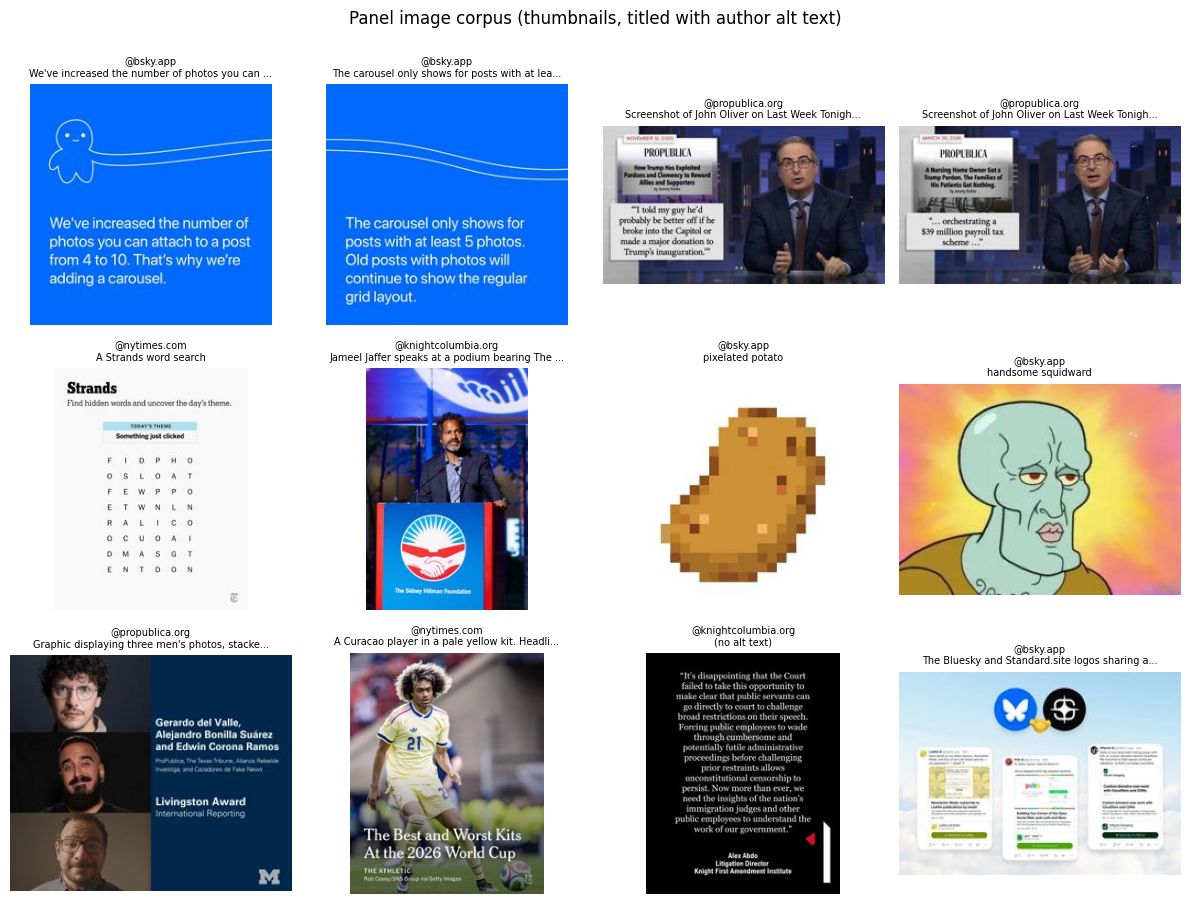

In [21]:
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, row in zip(axes.flat, manifest):
    ax.imshow(Image.open(row['file']))
    alt = row['alt_text'].strip().replace('\n', ' ')
    title = (alt[:45] + '...') if len(alt) > 45 else (alt or '(no alt text)')
    ax.set_title(f"@{row['author']}\n{title}", fontsize=7)
    ax.axis('off')

for ax in axes.flat[len(manifest):]:
    ax.axis('off')

fig.suptitle('Panel image corpus (thumbnails, titled with author alt text)', y=1.0)
plt.tight_layout()

## 7. From pixels to measurements: CLIP embeddings

Twelve images you can eyeball. Twelve thousand you cannot — at that scale you need a model that turns each image into numbers that preserve its meaning. An **embedding** is exactly that: a vector (here, 512 numbers) positioned so that similar things sit near each other and dissimilar things sit far apart — the same idea as the text embeddings of Part 06, now for pixels. The standard tool is **CLIP** ([Contrastive Language-Image Pre-training](https://arxiv.org/abs/2103.00020); Radford et al. 2021): a pair of neural networks, one for images and one for text, trained on hundreds of millions of caption-image pairs so that an image and a text describing it land near each other in the *same* embedding space.

That shared space buys you three analyses for free:

* **Clustering**: embed every image, run k-means or HDBSCAN on the vectors, and discover the corpus's visual genres (screenshots vs. photos vs. charts vs. memes) without labeling anything.
* **Zero-shot classification**: embed candidate labels as text ("a photograph of a crowd", "a screenshot of a social media post", "a data visualization") and assign each image the label it is most similar to — a classifier with no training data, just a codebook. ("Zero-shot" means the model has seen zero examples of your specific labels.)
* **Text-image agreement**: embed the post's text (or its alt text) and the image, and measure their cosine similarity — a direct operationalization of the multimodal question "does the image show what the words say?"

The cell below is a complete zero-shot pipeline over our thumbnail corpus using [`sentence-transformers`](https://www.sbert.net/examples/applications/image-search/README.html), which wraps CLIP behind the same `encode()` interface we used for text. Because CLIP's dependencies (PyTorch) are heavy, the cell skips itself gracefully when the library is not installed — install `sentence-transformers` and re-run to see the labels.

In [22]:
try:
    from sentence_transformers import SentenceTransformer, util

    # CLIP ViT-B/32: encodes images and text into the same 512-d space
    model = SentenceTransformer('clip-ViT-B-32')

    image_paths = sorted(Path('data/images').glob('*.jpg'))
    images = [Image.open(path) for path in image_paths]
    image_embeddings = model.encode(images, convert_to_tensor=True)

    # A tiny visual codebook: zero-shot labels phrased as captions
    labels = [
        'a screenshot of text or a user interface',
        'a photograph of one or more people',
        'a chart, map, or data visualization',
        'a logo or promotional graphic',
        'an outdoor scene or landscape',
    ]
    text_embeddings = model.encode(labels, convert_to_tensor=True)

    # Cosine similarity between every image and every label
    similarities = util.cos_sim(image_embeddings, text_embeddings)

    for path, row in zip(image_paths, similarities):
        best = int(row.argmax())
        print(f"{path.name}  ->  {labels[best]}  (cosine = {float(row[best]):.2f})")

    # For clustering instead: from sklearn.cluster import KMeans
    # KMeans(n_clusters=4).fit_predict(image_embeddings.cpu().numpy())

except ImportError:
    print('sentence-transformers is not installed, so we skip the CLIP demo.')
    print('Install it (and its PyTorch dependency) to run this cell:')
    print('    pip install sentence-transformers')
    print('The code above is complete and runs unchanged once installed.')

sentence-transformers is not installed, so we skip the CLIP demo.
Install it (and its PyTorch dependency) to run this cell:
    pip install sentence-transformers
The code above is complete and runs unchanged once installed.


With embeddings in hand, **visual framing analysis** becomes tractable. Framing research asks not *whether* a topic is covered but *how it is shown*: is a protest depicted as a crowd exercising voice or as a confrontation with police? Is a politician photographed at a podium or in an unflattering candid? Are climate stories illustrated with polar bears or with flooded homes? Each of those contrasts is a pair of zero-shot labels away. The validation discipline from Part 06 applies with full force — you must hand-check a sample of CLIP's assignments against human judgment before trusting any prevalence estimate, and CLIP inherits the biases of its web-scraped training data, including documented disparities in how it represents people across demographic groups.

## 8. Saving and reloading the archive

Per this series' reproducibility conventions, we save the per-post classification table, the image manifest (already written in Section 6), and a metadata file recording when, who, and how we collected — the panel, the post cap, the feed filter, the repost exclusion, and the endpoint. The point of the metadata file is that every number in this notebook depends on those choices: anyone re-running the analysis (including you, six months from now) needs them to interpret, reproduce, or fairly criticize the results.

In [23]:
df.to_csv('data/media_summary.csv', index=False)

metadata = {
    'collected_at': COLLECTED_AT.isoformat(),
    'panel': PANEL,
    'posts_per_account': POSTS_PER_ACCOUNT,
    'feed_filter': 'posts_no_replies',
    'reposts_excluded': True,
    'endpoint': 'app.bsky.feed.getAuthorFeed (public AppView, raw JSON)',
}
with open('data/collection_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

for path in sorted(Path('data').rglob('*')):
    if path.is_file():
        print(f"{path.stat().st_size / 1024:>8.1f} KB  {path}")

     0.4 KB  data/collection_metadata.json
    11.5 KB  data/images/095869d9d1b85fdf.jpg
     8.5 KB  data/images/4d396020b49d5575.jpg
    18.1 KB  data/images/4d4df7f8a3f6827a.jpg
     4.5 KB  data/images/77d798dc1f68787a.jpg
     9.3 KB  data/images/7d3f4203fff6c2fe.jpg
     8.3 KB  data/images/9e01fe88df7ec22f.jpg
     6.2 KB  data/images/a55dcd2cbde53f16.jpg
    20.3 KB  data/images/a76befc9bb9d106d.jpg
    11.2 KB  data/images/aa5aaabe0d022919.jpg
     5.2 KB  data/images/ac152a06ebec73cb.jpg
    14.1 KB  data/images/ac2266ad46129698.jpg
    12.6 KB  data/images/cc61189b52becb0f.jpg
     8.7 KB  data/images/dffe1cdbbb4486c5.jpg
     6.1 KB  data/images/e6c55b740ed0fd88.jpg
     9.3 KB  data/images/e8285195dfd3f106.jpg
    11.2 KB  data/images/fa11971edec412c1.jpg
    16.7 KB  data/images/fb843871f84b8b91.jpg
     3.2 KB  data/images_manifest.csv
   177.3 KB  data/media_summary.csv


As a final check, we prove the round trip works: reload the table from disk and recompute a headline number without touching the network. Downstream analyses — and your readers — should be able to start from `data/` alone.

In [24]:
# Reload demo: the analysis is reproducible from disk alone
reloaded = pd.read_csv('data/media_summary.csv')
reloaded_images = reloaded[reloaded['n_images'] > 0]

print(f"Reloaded {len(reloaded)} posts from data/media_summary.csv")
print(f"Alt-text provision among image posts (all images described): "
      f"{(reloaded_images['n_images_with_alt'] == reloaded_images['n_images']).mean():.1%}")
reloaded['embed_class'].value_counts()

Reloaded 810 posts from data/media_summary.csv
Alt-text provision among image posts (all images described): 71.6%


embed_class
external             624
images                87
none                  38
record                34
video                 25
record_with_media      2
Name: count, dtype: int64

## Ethics and limitations

**Images are categorically more sensitive than text.** A post's words expose what someone chose to say; its photos can expose faces (the author's and bystanders'), legible street signs and license plates, home interiors, children, and EXIF-style contextual details the author never consciously chose to share. Highfield & Leaver (2016) flag exactly this: visual methods inherit all of text's ethical problems and add re-identification of *third parties who never posted anything*. Practices this notebook deliberately models, and that you should keep when scaling up:

* **Minimization.** We analyzed metadata (embed types, alt-text presence, aspect ratios, domains) wherever metadata sufficed, and downloaded pixels only for a 12-image demonstration corpus — thumbnails, not full-size blobs. Collect images only when your research question genuinely requires pixels, at the lowest resolution that answers it.
* **Public organizations over private individuals.** Our panel is organizational accounts plus the series' standing examples. Do not assemble face corpora of private individuals from their feeds, and never run face recognition on them; many such uses are unethical and, in several jurisdictions, illegal.
* **Deletion and withdrawal.** A saved image outlives the author's ability to delete it. Record collection dates (we did, in `collection_metadata.json`), re-check post existence before republishing any image, and treat image corpora as more deletion-sensitive than text archives.
* **Alt text is user data too.** Descriptions can contain names and contextual details; the same quoting cautions from earlier parts apply.

**Limitations** to carry into any write-up: this six-account convenience panel measures nothing about Bluesky overall — it demonstrates a method, and its alt-text rates are certainly inflated relative to the full network (early adopters with strong norms, organizational accounts). Bluesky's user base is itself unrepresentative of any general population. Embed lexicons evolve (we met `app.bsky.embed.gallery` mid-notebook), so classifiers need maintenance and saved raw responses. CDN thumbnails are re-encoded renditions, not the original blobs, which matters for forensic analyses. And CLIP-style models carry documented demographic and cultural biases that propagate directly into any measurement built on them.

## Exercises

These extend the notebook in roughly increasing order of effort. All of them run unauthenticated.

1. **Swap the panel.** Replace the four organizational accounts in `PANEL` with accounts from a community you know — sports media, scientists, artists — and update `OWN_DOMAINS` to match (remember that a handle and a website domain are not always the same, as with `boulderrl.bsky.social`). Re-run Sections 2–5: which findings replicate, and which were specific to news organizations?
2. **Grow the image corpus.** Raise `max_images` in Section 6 to 24 and adjust the grid in the display cell from `(3, 4)` to `(4, 6)`. Watch the printed KB total: thumbnails average roughly 10 KB each, and this part's `data/` directory should stay well under 2 MB.
3. **Audit video alt text.** Section 4 measured alt text for images only, but the [`app.bsky.embed.video`](https://docs.bsky.app/docs/advanced-guides/posts) lexicon has an `alt` field too. Inspect a video post's embed view with `describe_embed`-style code to find where `alt` lives, then compute the panel's video alt-text provision rate and compare it to the image rate.
4. **Alt-text rates across communities.** Pick two communities — two starter packs, or two of Part 03's network clusters — and sample 10–20 accounts from each. Compute per-community alt-text provision rates (report the image counts alongside the rates, since small accounts make noisy estimates). Do communities differ more than the accounts within them?
5. **Link-card domain ecology over time.** Raise `POSTS_PER_ACCOUNT` for the two big news accounts to 400–500, bucket their link-card posts by month using the `created_at` column (`pd.to_datetime` plus [`dt.to_period('M')`](https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.to_period.html)), and plot each account's own-domain share per month. Is Bluesky becoming more or less of a pure distribution channel for them?
6. **Validate the aspect-ratio genre guesses.** Section 3 claimed aspect ratios proxy for image genre. Hand-label the 12 thumbnails in `data/images` (screenshot / photograph / chart / promotional graphic), then check the labels against each image's aspect ratio in the manifest. Where does the cheap proxy fail, and would CLIP's zero-shot labels from Section 7 have done better?

## Research project ideas

Three research designs this notebook's pipeline supports, in increasing order of ambition.

**1. What moves accessibility norms? Alt text as a natural experiment.** *Question:* what actually changes alt-text provision — platform nudges (the require-alt-text setting, badging of undescribed images), community enforcement (the stated "no alt text, no repost" norm), or tooling defaults (cross-posting schedulers that silently drop descriptions)? *Data:* a systematic sample of accounts stratified by join cohort and community (Part 03's clusters), with each account's image posts collected over its full tenure. *Method:* measure per-account provision rates and description lengths over time; use the event-study designs of Part 05 around datable shocks (a client adding alt-text badges, a high-profile norm campaign) to separate platform effects from community ones. [Gleason et al. (2019)](https://doi.org/10.1145/3308558.3313605) supplies both the Twitter baseline and the audit methodology; Bluesky supplies the variation in design and norms that Twitter lacked. *Expected challenge:* attributing posts to tooling is hard — posts do not reliably expose which client created them — so scheduler use must be inferred indirectly (posting-time regularity, simultaneous cross-platform publication), and that inference needs validation.

**2. Visual framing of a contested topic.** *Question:* when different communities post about the same event — a protest, an election, a climate disaster — do they *show* it differently, not just describe it differently? *Data:* images attached to topical posts collected with the search and snowball machinery of Part 02, joined to community labels from Part 03's network clustering. *Method:* embed every image with CLIP; develop a framing codebook from a hand-coded sample (crowd-as-voice vs. confrontation-with-police; podium portrait vs. unflattering candid); apply it at scale via zero-shot classification; compare frame prevalence across communities and across Part 05's event windows. [Highfield & Leaver (2016)](https://doi.org/10.1080/22041451.2016.1155332) lay out the methodological agenda. *Expected challenge:* validation. Zero-shot labels must be checked against human coders before any prevalence claim, and CLIP inherits documented demographic and cultural biases from its web-scraped training data that can systematically distort exactly the framing categories you care about.

**3. Multimodal text-image (dis)agreement.** *Question:* on which posts do the words and the pixels tell different stories, and is that divergence a usable signal — for sarcasm, for decorative imagery, or for the out-of-context images that drive much visual misinformation? *Data:* the full multimodal bundle each image post provides — post text, image pixels, and alt text as a third, author-written channel. *Method:* compute CLIP cosine similarities between all three channels per post; characterize the low-agreement tail with hand coding; test whether mismatch predicts independently identified miscontextualized images. *Expected challenge:* low similarity is not deception — jokes, abstractions, and decorative images all score low — so the design lives or dies on a labeled set of genuinely miscontextualized examples against which the mismatch signal can be evaluated.

## References

### Scholarship

* Highfield, T., & Leaver, T. (2016). Instagrammatics and digital methods: Studying visual social media, from selfies and GIFs to memes and emoji. *Communication Research and Practice*, 2(1), 47-62. [https://doi.org/10.1080/22041451.2016.1155332](https://doi.org/10.1080/22041451.2016.1155332)
* Gleason, C., Carrington, P., Cassidy, C., Morris, M. R., Kitani, K. M., & Bigham, J. P. (2019). "It's almost like they're trying to hide it": How user-provided image descriptions have failed to make Twitter accessible. *Proceedings of The World Wide Web Conference (WWW '19)*, 549-559. [https://doi.org/10.1145/3308558.3313605](https://doi.org/10.1145/3308558.3313605)
* Radford, A., Kim, J. W., Hallacy, C., et al. (2021). Learning transferable visual models from natural language supervision (CLIP). *Proceedings of the 38th International Conference on Machine Learning (ICML)*. [https://arxiv.org/abs/2103.00020](https://arxiv.org/abs/2103.00020)

* WebAIM: [Alternative Text](https://webaim.org/techniques/alttext/) — the standard practical guide to writing alt text.
* Bluesky: [Settings > Accessibility > Require alt text before posting](https://bsky.app/settings/accessibility).

### Documentation

* Bluesky Documentation: [Post embeds (images, video, link cards, quotes)](https://docs.bsky.app/docs/advanced-guides/posts), [rich text and facets](https://docs.bsky.app/docs/advanced-guides/post-richtext), [`app.bsky.feed.getAuthorFeed`](https://docs.bsky.app/docs/api/app-bsky-feed-get-author-feed), and the [HTTP API reference](https://docs.bsky.app/docs/api/at-protocol-xrpc-api).
* AT Protocol specifications: [Lexicon](https://atproto.com/specs/lexicon), [Blobs](https://atproto.com/specs/blob), [XRPC](https://atproto.com/specs/xrpc).
* The [atproto Python SDK](https://atproto.blue/).
* [Pillow handbook](https://pillow.readthedocs.io/en/stable/handbook/index.html) and the [`Image` module reference](https://pillow.readthedocs.io/en/stable/reference/Image.html).
* Matplotlib: [`imshow`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.imshow.html) and [image tutorial](https://matplotlib.org/stable/tutorials/images.html).
* sentence-transformers: [image search and CLIP examples](https://www.sbert.net/examples/applications/image-search/README.html).